True slope: 1.8332705429618212
Fitted slope (your method): 1.9651698922426264
Fitted slope (NumPy): 1.9651698922426248
True intercept: 0.8717534215091188
Fitted intercept (your method): 1.2730452878051701
Fitted intercept (NumPy): 1.2730452878051697
Largest residual: 0.5858253312219983 at X = 0.07
Smallest residual: -0.46417529198035723 at X = 0.67


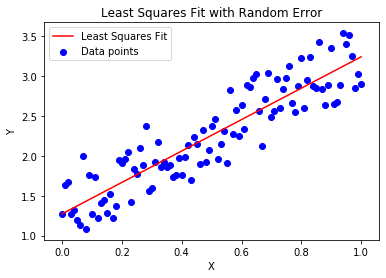

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def leastSquares(X, Y):
    n = len(X)
    sum_x = np.sum(X)
    sum_y = np.sum(Y)
    sum_xy = np.sum(X * Y)
    sum_x2 = np.sum(X ** 2)

    m = (n*sum_xy - sum_x*sum_y) / (n*sum_x2 - sum_x**2)
    c = (sum_y - m*sum_x) / n

    return m, c

m_true = np.random.rand()*5
b_true = np.random.rand()*5

X = np.arange(0, 1.01, 0.01)
X.sort()

noise = np.random.rand(len(X))
Y = m_true*X + b_true + noise

m_calc, c_calc = leastSquares(X, Y)

A = np.vstack([X, np.ones(len(X))]).T
m_np, c_np = np.linalg.lstsq(A, Y, rcond=None)[0]

print("True slope:", m_true)
print("Fitted slope (your method):", m_calc)
print("Fitted slope (NumPy):", m_np)
print("True intercept:", b_true)
print("Fitted intercept (your method):", c_calc)
print("Fitted intercept (NumPy):", c_np)

Y_pred = m_calc*X + c_calc
residuals = Y - Y_pred

max_index = np.argmax(residuals)
min_index = np.argmin(residuals)

print("Largest residual:", residuals[max_index], "at X =", X[max_index])
print("Smallest residual:", residuals[min_index], "at X =", X[min_index])

plt.scatter(X, Y, color='blue', label='Data points')
plt.plot(X, Y_pred, color='red', label='Least Squares Fit')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Least Squares Fit with Random Error')
plt.legend()
plt.show()